In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

pre_tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

pre_tree.fit(X_train, y_train)

y_pred_pre = pre_tree.predict(X_test)

accuracy_pre = accuracy_score(y_test, y_pred_pre)
precision_pre = precision_score(y_test, y_pred_pre)
recall_pre = recall_score(y_test, y_pred_pre)
f1_pre = f1_score(y_test, y_pred_pre)

print("\n===== DECISION TREE - PRE PRUNING =====")
print("Accuracy :", accuracy_pre)
print("Precision:", precision_pre)
print("Recall   :", recall_pre)
print("F1 Score :", f1_pre)

post_tree = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=0.01
)

post_tree.fit(X_train, y_train)

y_pred_post = post_tree.predict(X_test)

accuracy_post = accuracy_score(y_test, y_pred_post)
precision_post = precision_score(y_test, y_pred_post)
recall_post = recall_score(y_test, y_pred_post)
f1_post = f1_score(y_test, y_pred_post)

print("\n===== DECISION TREE - POST PRUNING =====")
print("Accuracy :", accuracy_post)
print("Precision:", precision_post)
print("Recall   :", recall_post)
print("F1 Score :", f1_post)



Dataset shape: (569, 30)
Target shape: (569,)

===== DECISION TREE - PRE PRUNING =====
Accuracy : 0.9298245614035088
Precision: 0.9571428571428572
Recall   : 0.9305555555555556
F1 Score : 0.9436619718309859

===== DECISION TREE - POST PRUNING =====
Accuracy : 0.9385964912280702
Precision: 0.9577464788732394
Recall   : 0.9444444444444444
F1 Score : 0.951048951048951


In [5]:
logistic_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='l2',
        max_iter=5000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)

print("\n===== LOGISTIC REGRESSION =====")
print("Accuracy :", accuracy_logistic)
print("Precision:", precision_logistic)
print("Recall   :", recall_logistic)
print("F1 Score :", f1_logistic)




===== LOGISTIC REGRESSION =====
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112


In [12]:
lasso_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='l1',
        solver='liblinear',
        C=0.1,
        max_iter=5000,
        random_state=42
    ))
])

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
precision_lasso = precision_score(y_test, y_pred_lasso)
recall_lasso = recall_score(y_test, y_pred_lasso)
f1_lasso = f1_score(y_test, y_pred_lasso)

print("\n===== LASSO - L1 LOGISTIC REGRESSION =====")
print("Accuracy :", accuracy_lasso)
print("Precision:", precision_lasso)
print("Recall   :", recall_lasso)
print("F1 Score :", f1_lasso)




===== LASSO - L1 LOGISTIC REGRESSION =====
Accuracy : 0.956140350877193
Precision: 0.971830985915493
Recall   : 0.9583333333333334
F1 Score : 0.965034965034965


In [13]:
ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='l2',
        solver='liblinear',
        C=0.1,
        max_iter=5000,
        random_state=42
    ))
])

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

accuracy_ridge = accuracy_score(y_test, y_pred_ridge)
precision_ridge = precision_score(y_test, y_pred_ridge)
recall_ridge = recall_score(y_test, y_pred_ridge)
f1_ridge = f1_score(y_test, y_pred_ridge)

print("\n===== RIDGE - L2 LOGISTIC REGRESSION =====")
print("Accuracy :", accuracy_ridge)
print("Precision:", precision_ridge)
print("Recall   :", recall_ridge)
print("F1 Score :", f1_ridge)




===== RIDGE - L2 LOGISTIC REGRESSION =====
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112


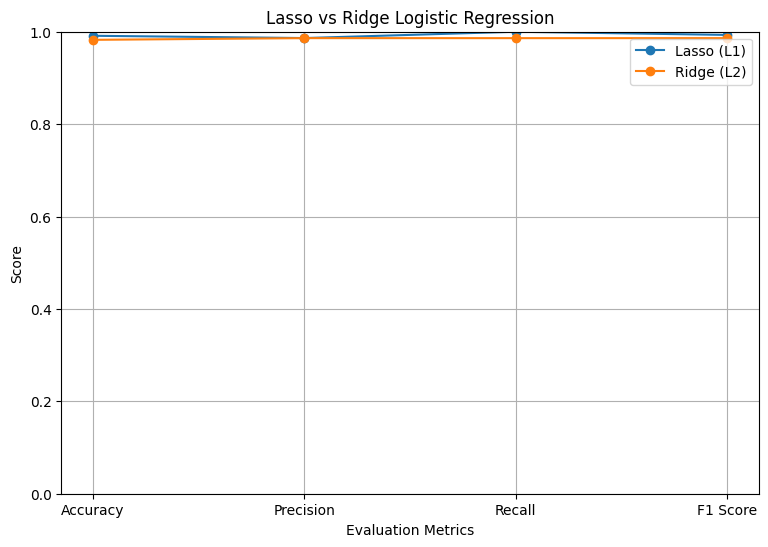

In [10]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

lasso_scores = [
    accuracy_lasso,
    precision_lasso,
    recall_lasso,
    f1_lasso
]

ridge_scores = [
    accuracy_ridge,
    precision_ridge,
    recall_ridge,
    f1_ridge
]

plt.figure(figsize=(9, 6))

plt.plot(metrics, lasso_scores, marker='o', label='Lasso (L1)')
plt.plot(metrics, ridge_scores, marker='o', label='Ridge (L2)')

plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("Lasso vs Ridge Logistic Regression")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

plt.show()